# Statistical Analysis of UK Historic Weather

**Author:** Aslı Akel  
**Programme:** MSc Data Science and Artificial Intelligence

This project investigates long-term changes in temperature, rainfall, and air-frost occurrence across 37 UK weather stations. It combines exploratory time-series analysis, seasonal regression, moving-block bootstrap confidence intervals, projection uncertainty, chi-squared tests, and false-discovery-rate control.

The analysis uses monthly historic station data published by the UK Met Office. It is a revised portfolio implementation designed to make assumptions, uncertainty, and limitations explicit.

## 1. Setup and reproducibility

The random seed is fixed. All paths are repository-relative, and the notebook validates the expected schema before analysis.

In [1]:
from pathlib import Path
import calendar
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import chi2_contingency

SEED = 42
RNG = np.random.default_rng(SEED)
DATA_DIR = Path("data")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

print("Random seed:", SEED)
print("Data directory:", DATA_DIR)

Random seed: 42
Data directory: data


## 2. Load and validate the station data

The source files contain monthly mean daily maximum and minimum temperatures, days of air frost, total rainfall, and sunshine duration. Missing values remain missing; they are never replaced with zero.

In [2]:
station_info = pd.read_csv(DATA_DIR / "ALL-WEATHER-STATIONS.csv", encoding="utf-8-sig")
station_info = station_info.rename(columns={"Longnitude": "Longitude"})

required_metadata = {"Name", "Longitude", "Latitude", "Opened", "Latest", "FileName"}
assert required_metadata.issubset(station_info.columns)

required_weather = {"Year", "Month", "TMax", "TMin", "Frost", "Rainfall", "Sunshine", "Status"}
stations = {}

for row in station_info.itertuples(index=False):
    path = DATA_DIR / f"{row.FileName}.csv"
    frame = pd.read_csv(path, na_values=["N/A", "---"])
    assert required_weather.issubset(frame.columns), f"Unexpected schema: {path.name}"

    frame["Date"] = pd.to_datetime(
        {"year": frame["Year"], "month": frame["Month"], "day": 15},
        errors="coerce",
    )
    frame = frame.sort_values("Date").drop_duplicates(["Year", "Month"]).reset_index(drop=True)
    frame["Station"] = row.Name
    frame["FileName"] = row.FileName
    stations[row.FileName] = frame

print(f"Loaded {len(stations)} stations.")
print(f"Observation range: {min(x.Date.min() for x in stations.values()).date()} to "
      f"{max(x.Date.max() for x in stations.values()).date()}")
display(station_info.head())

Loaded 37 stations.
Observation range: 1853-01-15 to 2025-09-15


,Name,Longitude,Latitude,Opened,Latest,FileName
0,Aberporth,-4.570,52.139,1941,2025,aberporthdata
1,Armagh,-6.649,54.352,1853,2025,armaghdata
2,Ballypatrick Forest,-6.153,55.181,1961,2025,ballypatrickdata
3,Bradford,-1.772,53.813,1908,2025,bradforddata
4,Braemar No 2,-3.396,57.011,1959,2025,braemardata


In [3]:
quality_rows = []
for key, frame in stations.items():
    expected_months = pd.period_range(frame.Date.min(), frame.Date.max(), freq="M").size
    quality_rows.append({
        "Station": frame["Station"].iloc[0],
        "Start": frame.Date.min().date(),
        "End": frame.Date.max().date(),
        "Rows": len(frame),
        "Missing calendar months": expected_months - len(frame),
        "TMax missing (%)": 100 * frame.TMax.isna().mean(),
        "Frost missing (%)": 100 * frame.Frost.isna().mean(),
        "Rainfall missing (%)": 100 * frame.Rainfall.isna().mean(),
    })

quality_df = pd.DataFrame(quality_rows).sort_values("Start")
display(quality_df.round(2))
print("Total station-month rows:", f"{sum(len(x) for x in stations.values()):,}")

,Station,Start,End,Rows,Missing calendar months,TMax missing (%),Frost missing (%),Rainfall missing (%)
1,Armagh,1853-01-15,2025-09-15,2073,0,7.09,7.09,0.05
22,Oxford,1853-01-15,2025-09-15,2073,0,0.00,0.05,0.00
28,Southampton Mayflower Park,1855-01-15,2000-03-15,1743,0,0.63,1.84,0.06
29,Stornoway Airport,1873-07-15,2025-09-15,1827,0,0.16,0.33,0.11
11,Durham,1880-01-15,2025-09-15,1749,0,0.06,0.06,0.00
27,Sheffield,1883-01-15,2025-09-15,1713,0,1.40,1.40,0.00
3,Bradford,1908-01-15,2025-09-15,1413,0,0.64,0.64,2.55
13,Eskdalemuir,1911-01-15,2025-09-15,1377,0,2.61,37.47,0.00
18,Lowestoft Monckton Avenue,1914-01-15,2010-10-15,1150,12,3.83,17.39,5.48
35,Wick Airport,1914-01-15,2025-09-15,1341,0,0.52,15.29,0.00


Total station-month rows: 39,427


The stations have different opening dates and some have closed. Consequently, comparisons use each station's available record and explicitly report uncertainty; they should not be interpreted as a spatially uniform monitoring panel.

## 3. Exploratory evidence

Four geographically varied stations illustrate long-term behaviour. Annual averages are computed only from observed monthly values. The lines are descriptive rather than causal estimates.

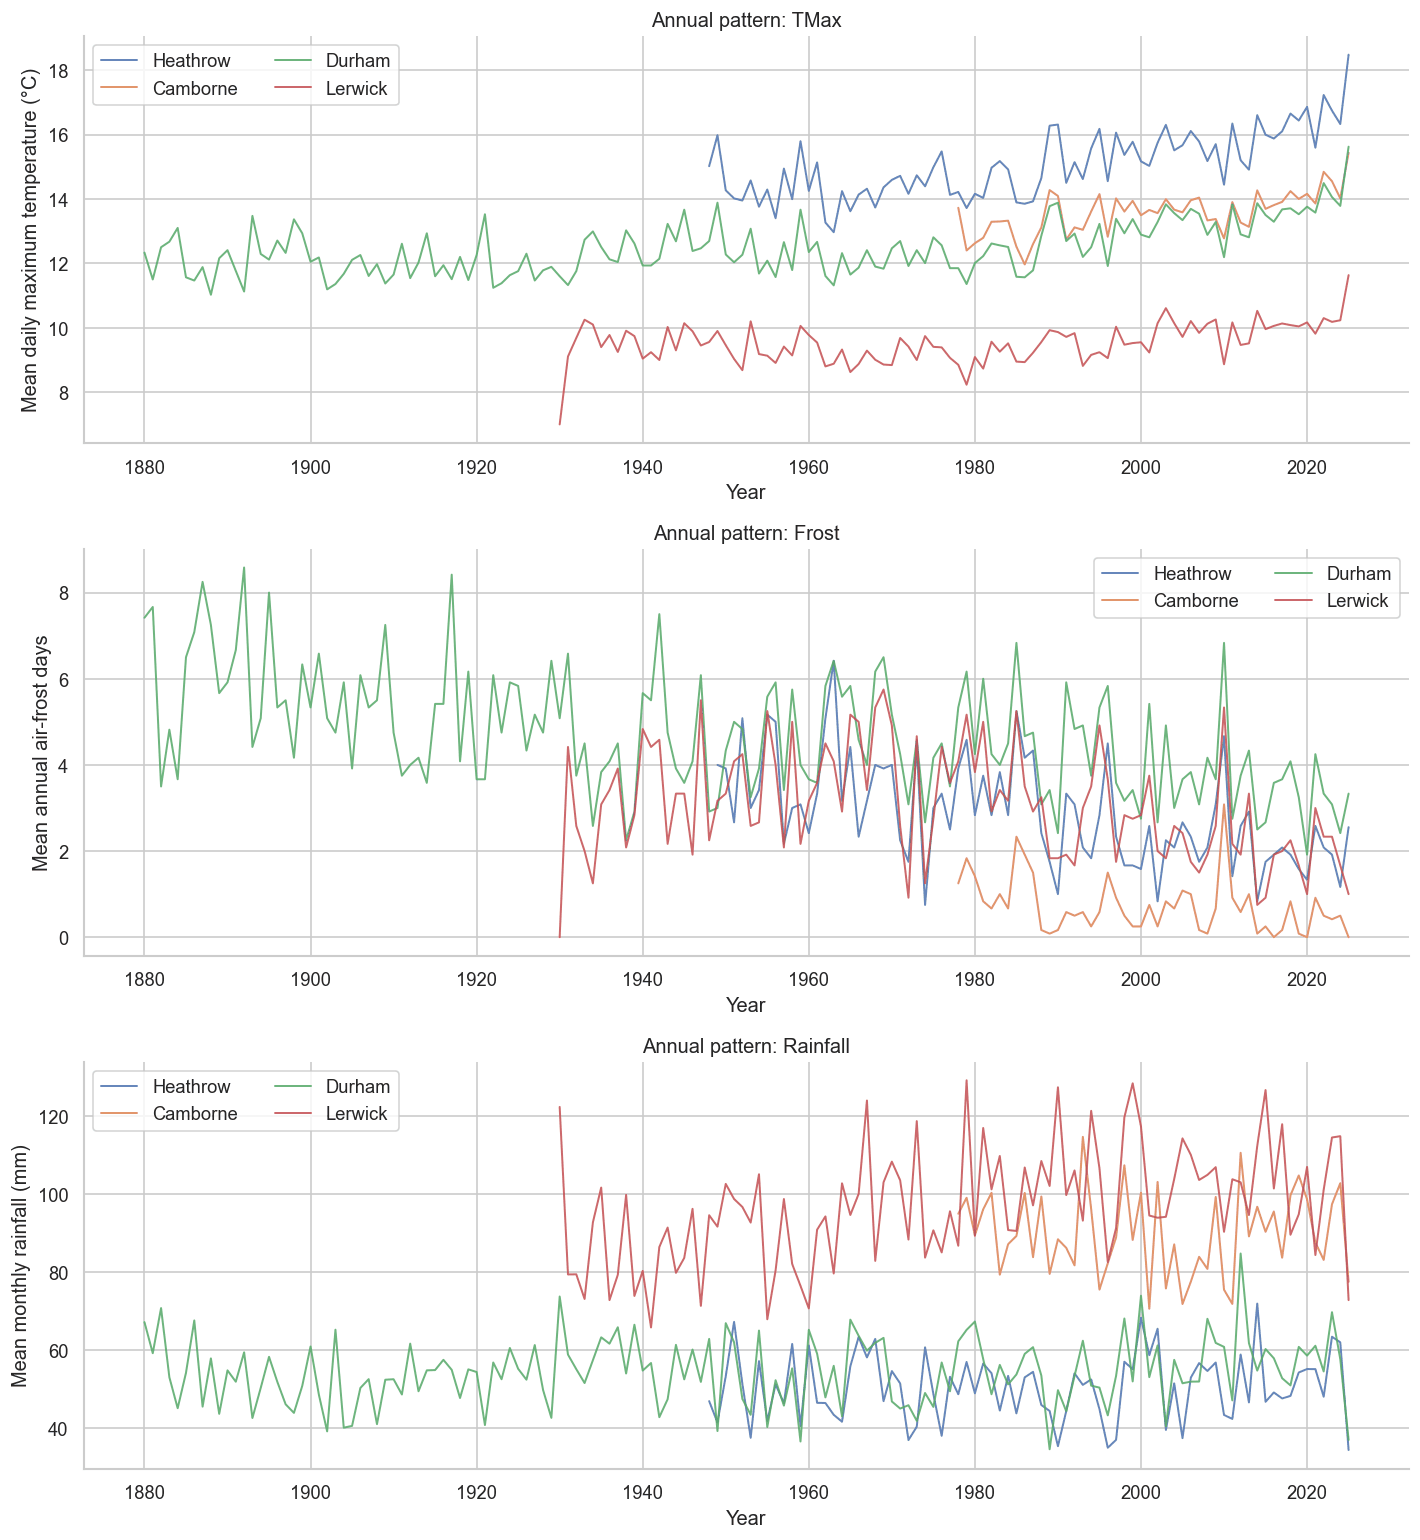

In [4]:
selected = ["heathrowdata", "cambornedata", "durhamdata", "lerwickdata"]
variables = {
    "TMax": "Mean daily maximum temperature (°C)",
    "Frost": "Mean annual air-frost days",
    "Rainfall": "Mean monthly rainfall (mm)",
}

fig, axes = plt.subplots(3, 1, figsize=(12, 13), sharex=False)
for ax, (variable, ylabel) in zip(axes, variables.items()):
    for key in selected:
        frame = stations[key]
        annual = frame.groupby("Year")[variable].mean().dropna()
        ax.plot(annual.index, annual.values, linewidth=1.2, alpha=0.85,
                label=frame["Station"].iloc[0])
    ax.set(title=f"Annual pattern: {variable}", ylabel=ylabel, xlabel="Year")
    ax.legend(ncol=2, frameon=True)
plt.tight_layout()
plt.show()

Temperature shows the clearest shared upward movement. Frost occurrence generally declines, whereas rainfall exhibits substantial year-to-year variability and less uniform direction. Formal modelling below focuses on temperature trends and frost-frequency change.

## 4. Seasonal temperature-trend model

For each station, monthly maximum temperature is modelled as

$$T_t = \beta_0 + \beta_1 t + \beta_2\sin(2\pi m/12) + \beta_3\cos(2\pi m/12) + \varepsilon_t,$$

where $t$ is elapsed calendar time in years and $m$ is calendar month. Using elapsed dates prevents missing months from being compressed into a false continuous sequence. The trend is reported in °C per decade.

In [5]:
def design_temperature(frame):
    data = frame.dropna(subset=["Date", "TMax"]).copy()
    origin = data["Date"].min()
    data["TimeYears"] = (data["Date"] - origin).dt.days / 365.2425
    angle = 2 * np.pi * (data["Month"] - 1) / 12
    X = pd.DataFrame({
        "const": 1.0,
        "TimeYears": data["TimeYears"],
        "sin12": np.sin(angle),
        "cos12": np.cos(angle),
    }, index=data.index)
    return data, X, origin


def fit_temperature(frame):
    data, X, origin = design_temperature(frame)
    model = sm.OLS(data["TMax"], X).fit(cov_type="HAC", cov_kwds={"maxlags": 12})
    return data, X, origin, model


heathrow_data, heathrow_X, _, heathrow_model = fit_temperature(stations["heathrowdata"])
print(heathrow_model.summary().tables[1])
print(f"Heathrow trend: {heathrow_model.params['TimeYears'] * 10:.3f} °C per decade")
print(f"HAC 95% CI: [{heathrow_model.conf_int().loc['TimeYears', 0] * 10:.3f}, "
      f"{heathrow_model.conf_int().loc['TimeYears', 1] * 10:.3f}]")

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         13.8244      0.186     74.450      0.000      13.460      14.188
TimeYears      0.0314      0.004      8.107      0.000       0.024       0.039
sin12         -0.6451      0.084     -7.694      0.000      -0.809      -0.481
cos12         -7.7780      0.092    -84.227      0.000      -7.959      -7.597
Heathrow trend: 0.314 °C per decade
HAC 95% CI: [0.238, 0.390]


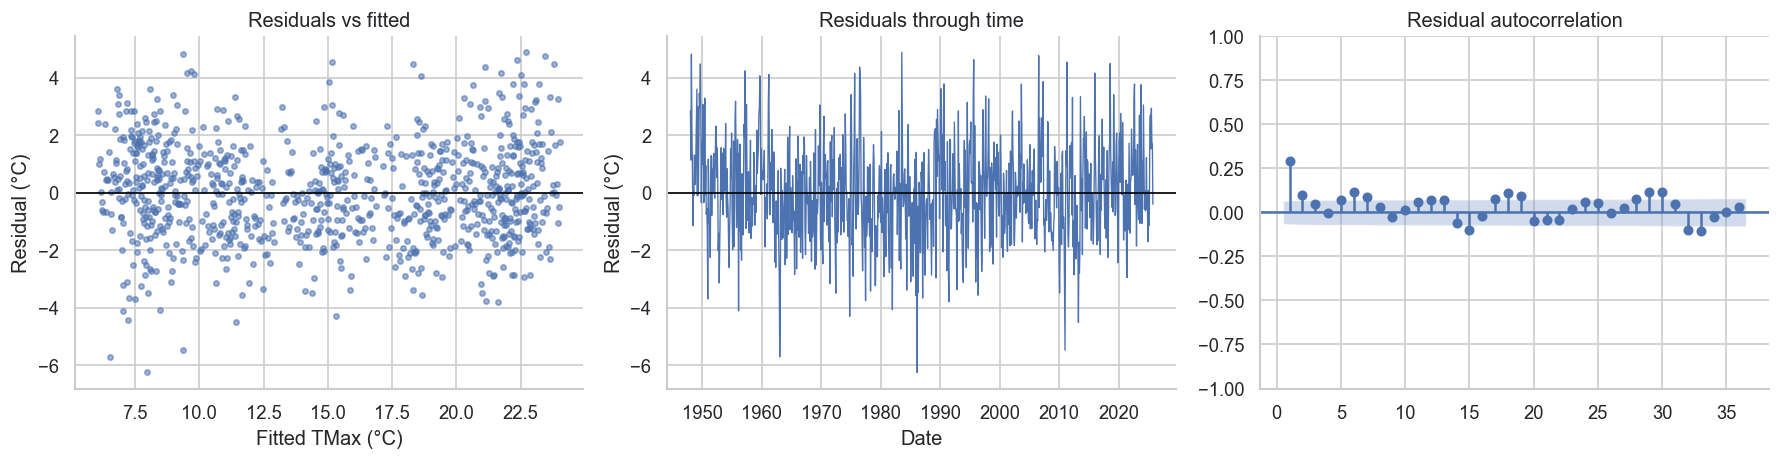

In [6]:
fitted = heathrow_model.predict(heathrow_X)
residuals = heathrow_data["TMax"] - fitted

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(fitted, residuals, s=10, alpha=0.55)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set(xlabel="Fitted TMax (°C)", ylabel="Residual (°C)", title="Residuals vs fitted")
axes[1].plot(heathrow_data["Date"], residuals, linewidth=0.8)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set(xlabel="Date", ylabel="Residual (°C)", title="Residuals through time")
sm.graphics.tsa.plot_acf(residuals, lags=36, ax=axes[2], zero=False)
axes[2].set_title("Residual autocorrelation")
plt.tight_layout()
plt.show()

Residual autocorrelation is expected in monthly climate observations. Therefore, independent residual resampling would understate temporal dependence. The portfolio version uses a circular moving-block bootstrap with 12-month blocks and also reports HAC-robust regression intervals.

In [7]:
def moving_block_sample(residuals, rng, block_length=12):
    residuals = np.asarray(residuals)
    n = len(residuals)
    starts = rng.integers(0, n, size=int(np.ceil(n / block_length)))
    sampled = np.concatenate([
        residuals[(start + np.arange(block_length)) % n] for start in starts
    ])[:n]
    return sampled


def bootstrap_trend(frame, B=500, block_length=12, seed=SEED):
    data, X, _, model = fit_temperature(frame)
    y_hat = np.asarray(model.fittedvalues)
    residuals = np.asarray(data["TMax"] - y_hat)
    Xv = X.to_numpy()
    pinv = np.linalg.pinv(Xv)
    rng = np.random.default_rng(seed)
    slopes = np.empty(B)
    for b in range(B):
        y_boot = y_hat + moving_block_sample(residuals, rng, block_length)
        slopes[b] = (pinv @ y_boot)[1] * 10
    estimate = model.params["TimeYears"] * 10
    return estimate, np.quantile(slopes, [0.025, 0.975]), slopes, model


trend_rows = []
trend_bootstraps = {}
for i, (key, frame) in enumerate(stations.items()):
    estimate, interval, draws, model = bootstrap_trend(frame, seed=SEED + i)
    trend_bootstraps[key] = draws
    trend_rows.append({
        "Station": frame["Station"].iloc[0],
        "FileName": key,
        "Record years": (frame.Date.max() - frame.Date.min()).days / 365.2425,
        "Trend °C/decade": estimate,
        "Bootstrap CI low": interval[0],
        "Bootstrap CI high": interval[1],
        "HAC p-value": model.pvalues["TimeYears"],
        "R²": model.rsquared,
    })

trend_df = pd.DataFrame(trend_rows).sort_values("Trend °C/decade", ascending=False)
display(trend_df.round(4))

,Station,FileName,Record years,Trend °C/decade,Bootstrap CI low,Bootstrap CI high,HAC p-value,R²
34,Whitby,whitbydata,64.0013,0.5022,0.4409,0.5752,0.0000,0.9039
7,Cardiff Bute Park,cardiffdata,48.0010,0.4063,0.2968,0.5250,0.0000,0.9155
12,Eastbourne,eastbournedata,66.6680,0.3832,0.3174,0.4565,0.0000,0.9268
6,Cambridge Niab,cambridgedata,66.6680,0.3437,0.2575,0.4305,0.0000,0.9126
30,Sutton Bonington,suttonboningtondata,66.6680,0.3295,0.2519,0.4042,0.0000,0.9125
14,Heathrow,heathrowdata,77.6689,0.3137,0.2484,0.3855,0.0000,0.9174
10,Dunstaffnage,dunstaffnagedata,54.2544,0.3096,0.2390,0.3897,0.0000,0.9186
5,Camborne,cambornedata,47.0016,0.3040,0.2080,0.4060,0.0000,0.9060
15,Hurn,hurndata,68.6667,0.3026,0.2300,0.3738,0.0000,0.9159
36,Yeovilton,yeoviltondata,61.0006,0.2872,0.2015,0.3593,0.0000,0.9110


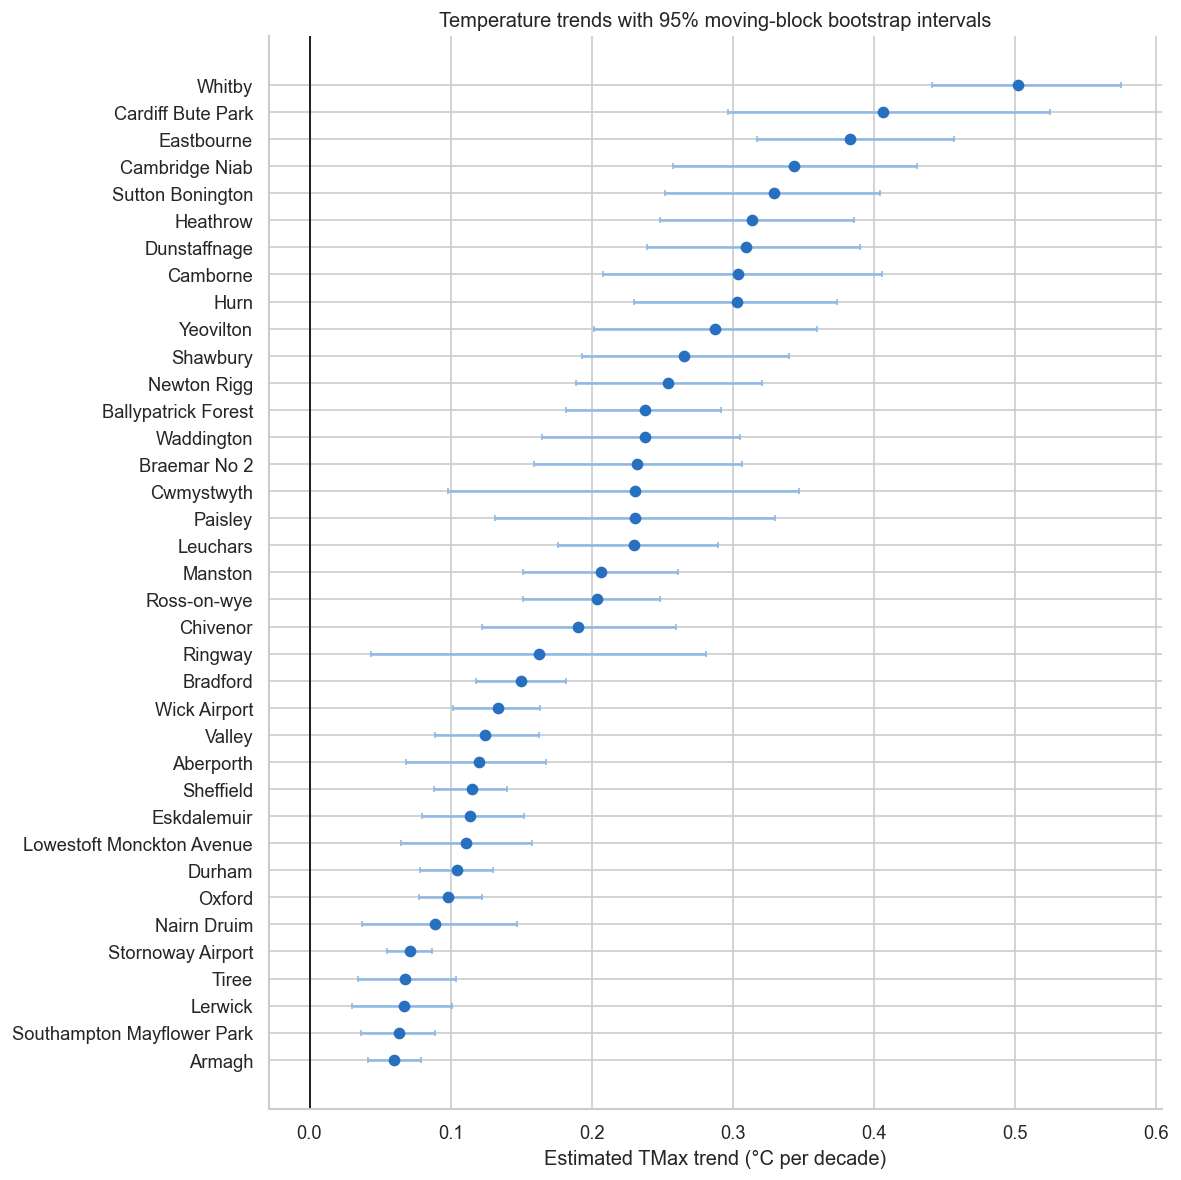

Stations with a 95% bootstrap interval entirely above zero: 37/37
Median estimated trend: 0.207 °C per decade


In [8]:
plot_df = trend_df.sort_values("Trend °C/decade")
fig, ax = plt.subplots(figsize=(10, 10))
x = plot_df["Trend °C/decade"]
ax.errorbar(
    x, plot_df["Station"],
    xerr=[x - plot_df["Bootstrap CI low"], plot_df["Bootstrap CI high"] - x],
    fmt="o", capsize=2, color="#276FBF", ecolor="#8EB8E5",
)
ax.axvline(0, color="black", linewidth=1)
ax.set(xlabel="Estimated TMax trend (°C per decade)", ylabel="",
       title="Temperature trends with 95% moving-block bootstrap intervals")
plt.tight_layout()
plt.show()

positive = (trend_df["Bootstrap CI low"] > 0).sum()
print(f"Stations with a 95% bootstrap interval entirely above zero: {positive}/{len(trend_df)}")
print(f"Median estimated trend: {trend_df['Trend °C/decade'].median():.3f} °C per decade")

## 5. August 2075 model projections

The following values are extrapolations of a linear seasonal model, not weather forecasts. They assume the historical linear trend continues unchanged to 2075 and do not incorporate emissions scenarios, physical climate dynamics, station relocation, or future model non-linearity. Prediction intervals include residual variability and bootstrap parameter uncertainty.

In [9]:
def august_projection(frame, future_year=2075, B=1000, block_length=12, seed=SEED):
    data, X, origin, model = fit_temperature(frame)
    future_date = pd.Timestamp(future_year, 8, 15)
    t_future = (future_date - origin).days / 365.2425
    angle = 2 * np.pi * 7 / 12
    x_future = np.array([1.0, t_future, np.sin(angle), np.cos(angle)])

    y_hat = np.asarray(model.fittedvalues)
    residuals = np.asarray(data["TMax"] - y_hat)
    pinv = np.linalg.pinv(X.to_numpy())
    rng = np.random.default_rng(seed)
    draws = np.empty(B)
    for b in range(B):
        sampled = moving_block_sample(residuals, rng, block_length)
        beta = pinv @ (y_hat + sampled)
        draws[b] = x_future @ beta + rng.choice(sampled)

    point = float(x_future @ model.params.to_numpy())
    historic_august = data.loc[data.Month.eq(8), "TMax"]
    return {
        "Station": data["Station"].iloc[0],
        "Historic August mean": historic_august.mean(),
        f"Projected August {future_year}": point,
        "Prediction interval low": np.quantile(draws, 0.025),
        "Prediction interval high": np.quantile(draws, 0.975),
        "Last observed year": int(data.Year.max()),
    }


highest_key = trend_df.iloc[0]["FileName"]
lowest_key = trend_df.iloc[-1]["FileName"]
projection_df = pd.DataFrame([
    august_projection(stations[highest_key], seed=SEED),
    august_projection(stations[lowest_key], seed=SEED + 1),
])
display(projection_df.round(2))

,Station,Historic August mean,Projected August 2075,Prediction interval low,Prediction interval high,Last observed year
0,Whitby,18.96,22.53,19.65,25.64,2025
1,Armagh,18.94,19.31,16.66,22.10,2025


The contrast illustrates how a simple linear model propagates different station-level trend estimates. Because 2075 lies far outside the observed period for some stations, uncertainty is not fully captured by these statistical intervals; scenario-based climate projections would be required for decision-making.

## 6. Change in air-frost frequency

Monthly `Frost` is a count of air-frost days. For every observed month, the denominator is its actual calendar-day count; missing months contribute neither frost nor non-frost days. This avoids treating incomplete years as if all 365 days had been observed.

In [10]:
def benjamini_hochberg(p_values):
    p = np.asarray(p_values, dtype=float)
    order = np.argsort(p)
    ranked = p[order]
    adjusted_ranked = np.minimum.accumulate((ranked * len(p) / np.arange(1, len(p) + 1))[::-1])[::-1]
    adjusted = np.empty_like(adjusted_ranked)
    adjusted[order] = np.clip(adjusted_ranked, 0, 1)
    return adjusted


def frost_test(frame):
    data = frame.dropna(subset=["Frost", "Date"]).copy()
    data["DaysObserved"] = [calendar.monthrange(int(y), int(m))[1]
                            for y, m in zip(data.Year, data.Month)]
    data["FrostDays"] = data["Frost"].clip(lower=0, upper=data["DaysObserved"])
    data["NonFrostDays"] = data["DaysObserved"] - data["FrostDays"]
    data["Decade"] = (data["Year"] // 10) * 10
    table = data.groupby("Decade")[["FrostDays", "NonFrostDays"]].sum()
    table = table.loc[table.sum(axis=1) > 0]
    chi2, p_value, dof, expected = chi2_contingency(table)

    rates = table["FrostDays"] / table.sum(axis=1)
    return {
        "Station": data["Station"].iloc[0],
        "Decades": len(table),
        "Chi-square": chi2,
        "Degrees of freedom": dof,
        "Raw p-value": p_value,
        "First decade": int(table.index.min()),
        "Latest decade": int(table.index.max()),
        "First frost rate": rates.iloc[0],
        "Latest frost rate": rates.iloc[-1],
        "Rate change (pp)": 100 * (rates.iloc[-1] - rates.iloc[0]),
    }, table


frost_rows, frost_tables = [], {}
for key, frame in stations.items():
    result, table = frost_test(frame)
    frost_rows.append(result)
    frost_tables[key] = table

frost_df = pd.DataFrame(frost_rows)
frost_df["BH-adjusted p-value"] = benjamini_hochberg(frost_df["Raw p-value"])
frost_df["Significant at FDR 5%"] = frost_df["BH-adjusted p-value"] < 0.05
frost_df = frost_df.sort_values("BH-adjusted p-value")
display(frost_df.round(5))
print("Stations significant after BH correction:",
      f"{frost_df['Significant at FDR 5%'].sum()}/{len(frost_df)}")

,Station,Decades,Chi-square,Degrees of freedom,Raw p-value,First decade,Latest decade,First frost rate,Latest frost rate,Rate change (pp),BH-adjusted p-value,Significant at FDR 5%
29,Stornoway Airport,16,509.19822,15,0.00000,1870,2020,0.14063,0.05524,-8.53935,0.00000,True
2,Ballypatrick Forest,7,305.00635,6,0.00000,1960,2020,0.12159,0.05000,-7.15865,0.00000,True
27,Sheffield,15,299.91549,14,0.00000,1880,2020,0.14470,0.05952,-8.51770,0.00000,True
11,Durham,15,282.24871,14,0.00000,1880,2020,0.20348,0.10000,-10.34787,0.00000,True
22,Oxford,18,268.11217,17,0.00000,1850,2020,0.16706,0.07476,-9.22960,0.00000,True
32,Valley,10,218.09130,9,0.00000,1930,2020,0.01055,0.02905,1.84991,0.00000,True
33,Waddington,9,189.96178,8,0.00000,1940,2020,0.09863,0.06810,-3.05349,0.00000,True
16,Lerwick,10,191.65999,9,0.00000,1930,2020,0.09253,0.06333,-2.91923,0.00000,True
19,Manston,7,176.55167,6,0.00000,1960,2020,0.11165,0.03571,-7.59377,0.00000,True
14,Heathrow,9,171.14600,8,0.00000,1940,2020,0.13151,0.06286,-6.86497,0.00000,True


Stations significant after BH correction: 36/37


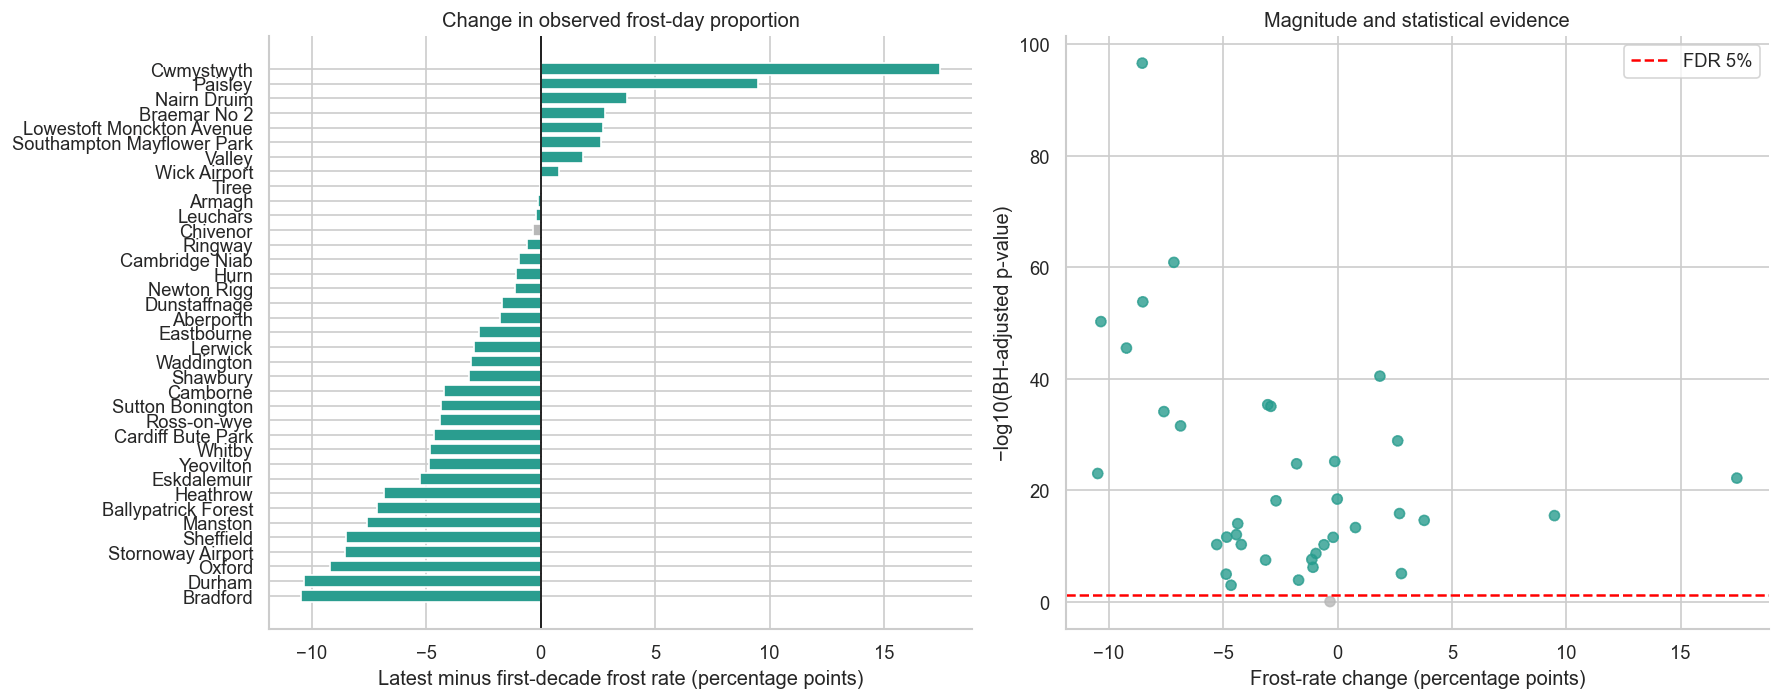

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

plot_frost = frost_df.sort_values("Rate change (pp)")
colors = np.where(plot_frost["Significant at FDR 5%"], "#2A9D8F", "#B8B8B8")
axes[0].barh(plot_frost["Station"], plot_frost["Rate change (pp)"], color=colors)
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set(xlabel="Latest minus first-decade frost rate (percentage points)",
            ylabel="", title="Change in observed frost-day proportion")

axes[1].scatter(frost_df["Rate change (pp)"], -np.log10(frost_df["BH-adjusted p-value"]),
                c=np.where(frost_df["Significant at FDR 5%"], "#2A9D8F", "#B8B8B8"), alpha=0.8)
axes[1].axhline(-np.log10(0.05), color="red", linestyle="--", label="FDR 5%")
axes[1].set(xlabel="Frost-rate change (percentage points)",
            ylabel="−log10(BH-adjusted p-value)", title="Magnitude and statistical evidence")
axes[1].legend()

plt.tight_layout()
plt.show()

The chi-squared tests establish whether frost-day proportions vary across decades; they do not by themselves prove a monotonic decline or identify a cause. The first-to-latest decade difference is shown as a transparent effect-size summary, while adjusted p-values control the false discovery rate across 37 simultaneous station tests.

## 7. Conclusions and limitations

- Maximum temperatures show positive long-term trends across the station records, with meaningful geographic variation in estimated rates.
- The moving-block bootstrap retains short-range temporal structure and is more defensible than independently resampling monthly residuals.
- Frost-day proportions change significantly at many stations even after multiple-testing correction, and the effect-size chart shows whether the latest observed decade is higher or lower than the first.
- Rainfall is more variable and does not display the same uniform descriptive pattern as temperature.
- Station records differ in duration, missingness, closure status, instrumentation, and local site conditions. Results describe these observed series rather than a perfectly balanced national network.
- Long-range linear extrapolations are illustrative model projections, not physical climate forecasts or causal estimates.

Together, the analyses provide statistical evidence of changing UK weather patterns while keeping uncertainty, multiplicity, temporal dependence, and data limitations visible.

## Data source

UK Met Office, *Historic station data*:  
<https://www.metoffice.gov.uk/research/climate/maps-and-data/historic-station-data>

The repository includes the small station extracts used for reproducibility and attributes the Met Office as the data source. Users should review the Met Office website terms and Open Government Licence provisions before reuse.